In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install yfinance

In [4]:
!pip install mplfinance

In [5]:
from datetime import datetime, timedelta
import pandas as pd
import yfinance as yf
import mplfinance as mpf
from datetime import datetime, timedelta

ticker_symbol = 'BBCA.JK'

data = yf.download(ticker_symbol, start='2024-01-01', end='2026-06-14')

[*********************100%***********************]  1 of 1 completed


In [6]:
# prompt: konversi nama kolom dari dua baris  menjadi satu baris nama kolom dari dataframe data

import pandas as pd

if isinstance(data.columns, pd.MultiIndex):

  data.columns = ['_'.join(col).strip() for col in data.columns.values]
else:

  data.columns = [str(col).strip() for col in data.columns]

# Print the updated dataframe to show the new column names
print(data.head())

            Close_BBCA.JK  High_BBCA.JK  Low_BBCA.JK  Open_BBCA.JK  \
Date                                                                 
2024-01-02    8464.398438   8464.398438  8397.042482   8441.946452   
2024-01-03    8397.041992   8464.397944  8374.590008   8464.397944   
2024-01-04    8509.301758   8509.301758  8419.493824   8441.945807   
2024-01-05    8599.110352   8621.562337  8509.302411   8531.754396   
2024-01-08    8599.110352   8644.014322  8509.302411   8621.562337   

            Volume_BBCA.JK  
Date                        
2024-01-02        30545200  
2024-01-03        34603300  
2024-01-04        56501800  
2024-01-05        85290100  
2024-01-08        50896000  


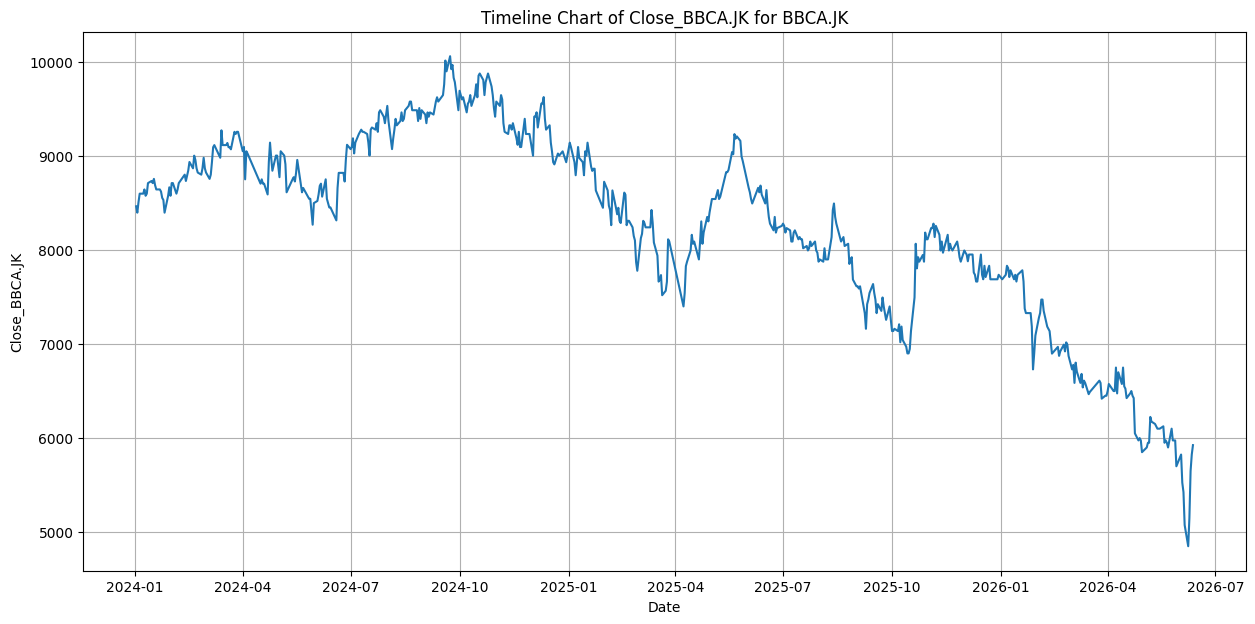

In [7]:
# prompt: buatkan chart timeline dengan sumbu x adalah kolom date dan sumbu y adalah Close_BBCA.JK

import matplotlib.pyplot as plt

# Assuming 'data' DataFrame is already loaded and processed with column 'Close'
# If 'Close_BBCA.JK' column exists (based on the previous flattening step, it would likely be 'Close'),
# we use that column. If not, we use the standard 'Close' column from yfinance.
# Let's explicitly check for 'Close_BBCA.JK' first as requested,
# but based on the previous code, the column name is likely just 'Close'.
# We will prioritize 'Close_BBCA.JK' if it exists, otherwise use 'Close'.

close_column_name = 'Close' # Default to the standard yfinance column name
if 'Close_BBCA.JK' in data.columns:
    close_column_name = 'Close_BBCA.JK'
elif 'Close' not in data.columns:
    print("Error: Neither 'Close_BBCA.JK' nor 'Close' column found in the DataFrame.")
    # Handle this error appropriately, maybe exit or return
else:
    print(f"Column 'Close_BBCA.JK' not found, using '{close_column_name}' instead.")


plt.figure(figsize=(15, 7)) # Adjust figure size as needed
plt.plot(data.index, data[close_column_name])
plt.xlabel('Date')
plt.ylabel(close_column_name)
plt.title(f'Timeline Chart of {close_column_name} for {ticker_symbol}')
plt.grid(True)
plt.show()


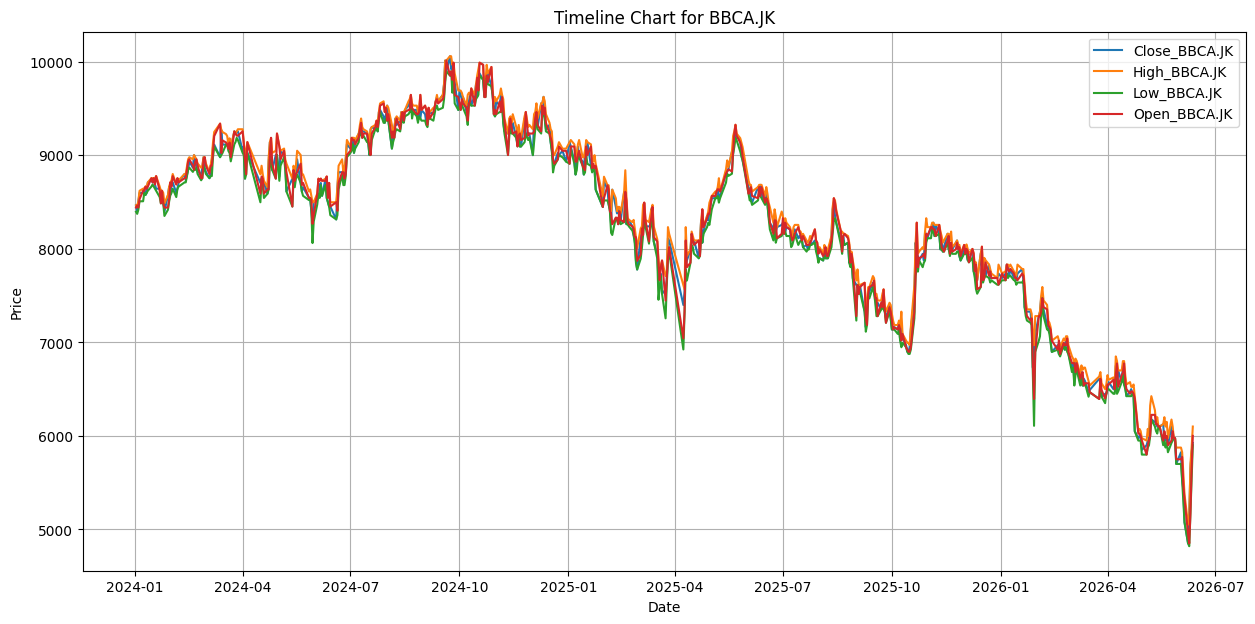

In [8]:
# prompt: buatkan chart timeline dengan sumbu x adalah kolom date dan sumbu y adalah Close_BBCA.JK,High_BBCA.JK , Low_BBCA.JK , Open_BBCA.JK

import matplotlib.pyplot as plt
plt.figure(figsize=(15, 7))
# Use the correct column names based on the previous cell's output/handling
plt.plot(data.index, data['Close_BBCA.JK'], label='Close_BBCA.JK')
plt.plot(data.index, data['High_BBCA.JK'], label='High_BBCA.JK') # Assuming High is still 'High', if not, change it
plt.plot(data.index, data['Low_BBCA.JK'], label='Low_BBCA.JK')   # Assuming Low is still 'Low', if not, change it
plt.plot(data.index, data['Open_BBCA.JK'], label='Open_BBCA.JK') # Assuming Open is still 'Open', if not, change it

plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'Timeline Chart for {ticker_symbol}')
plt.legend()
plt.grid(True)
plt.show()

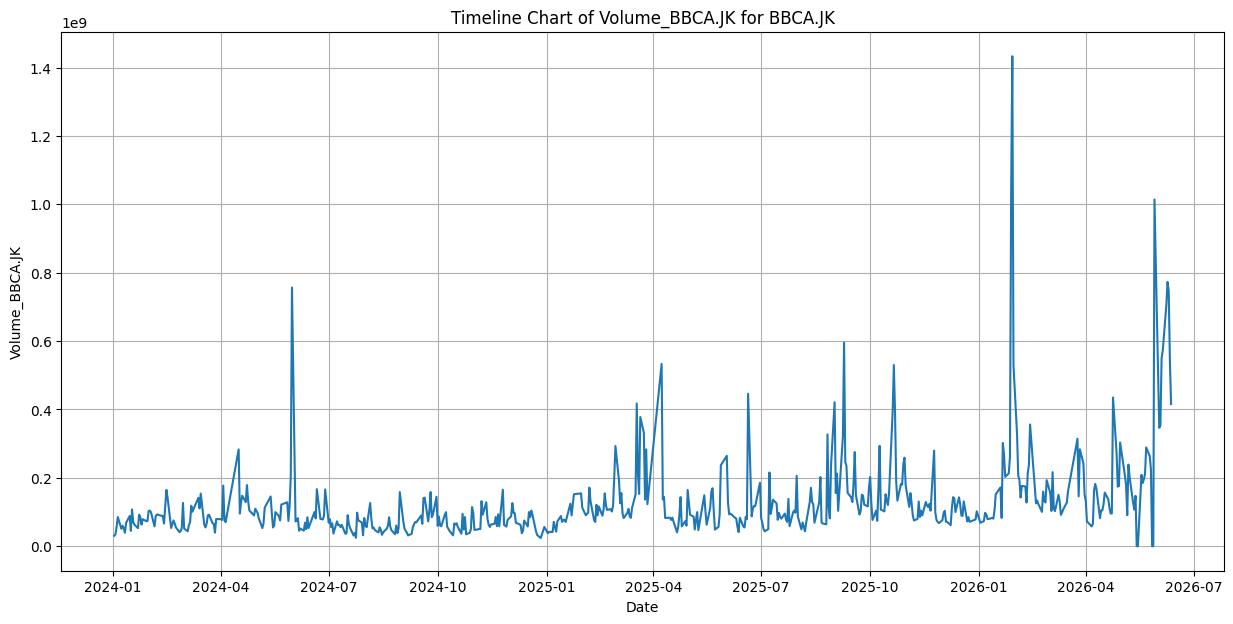

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(data.index, data['Volume_BBCA.JK'])
plt.xlabel('Date')
plt.ylabel('Volume_BBCA.JK')
plt.title(f'Timeline Chart of Volume_BBCA.JK for {ticker_symbol}')
plt.grid(True)
plt.show()

In [10]:
# This cell explains why greykite cannot be installed.
# In the previous attempt, installing `greykite` failed because its required dependency
# `pandas==1.5.3` could not be built in this environment.
# This error usually indicates an incompatibility with the underlying Python version (e.g., Python 3.12)
# or missing build tools that prevent older `pandas` versions from compiling.
# As a result, `greykite` cannot be installed in this Colab session.
# You can use the Prophet model instead, which ran successfully in a previous cell.
# If `greykite` is absolutely necessary, consider starting a fresh Colab notebook
# and attempting to install `greykite` (and its dependencies) before other libraries.

In [11]:
!pip install prophet

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


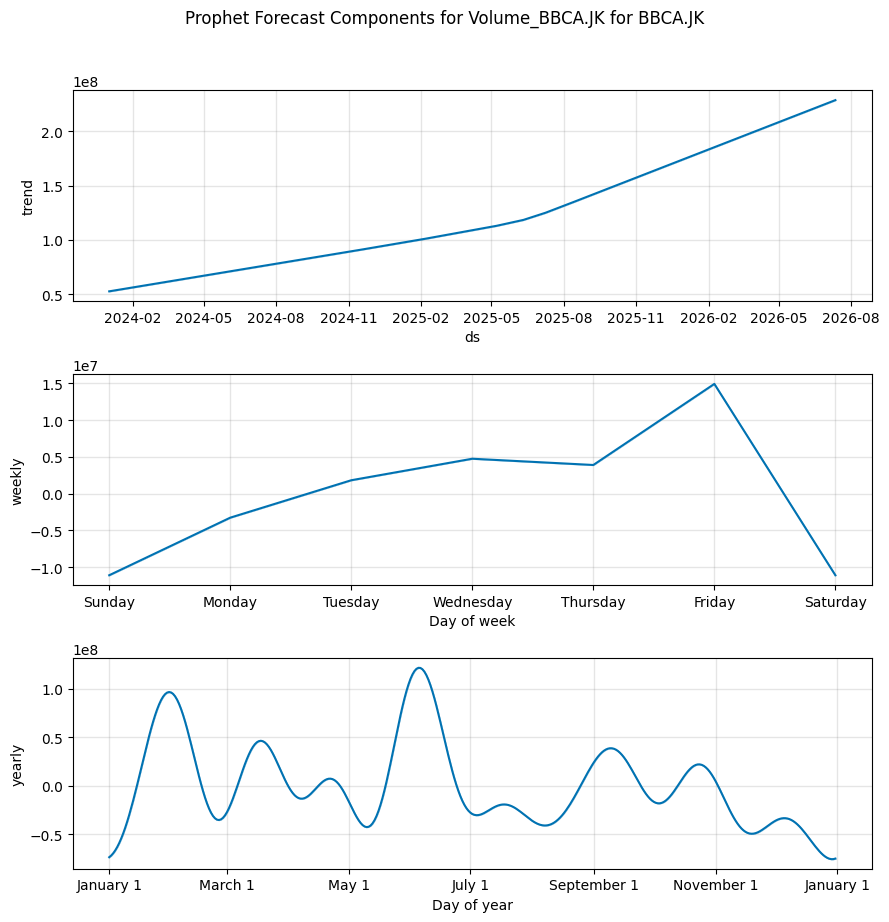

In [12]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Prepare the data for Prophet
# The 'data' DataFrame is already available from previous steps

df = data[['Volume_BBCA.JK']].reset_index()
df.rename(columns={'Date': 'ds', 'Volume_BBCA.JK': 'y'}, inplace=True)

# Ensure 'ds' column is datetime type and 'y' is numeric
df['ds'] = pd.to_datetime(df['ds'])
df["y"] = pd.to_numeric(df["y"])

# Prophet can handle missing values, but for a simple case, we can forward fill
df['y'] = df['y'].fillna(method='ffill')

# Initialize and fit the Prophet model
model = Prophet()
model.fit(df)

# Define the forecast period
future_periods = 30  # Forecast for the next 30 days
future = model.make_future_dataframe(periods=future_periods)

# Make predictions
forecast = model.predict(future)

# Plot the components
fig_components = model.plot_components(forecast)
plt.suptitle(f'Prophet Forecast Components for Volume_BBCA.JK for {ticker_symbol}', y=1.02) # Add a main title
plt.tight_layout()
plt.show()

### Model Evaluation Metrics

To evaluate the Prophet model's performance, we'll use two common metrics:

*   **Mean Absolute Percentage Error (MAPE)**: This metric expresses the accuracy as a percentage of the error. A lower MAPE indicates a more accurate model. It's particularly useful when you want to understand the error in terms of the scale of the actual values.
    $MAPE = \frac{1}{n} \sum_{t=1}^{n} \left| \frac{A_t - F_t}{A_t} \right| \times 100\%$

*   **Root Mean Squared Error (RMSE)**: This metric measures the average magnitude of the errors. It is the square root of the average of the squared differences between prediction and actual observation. RMSE penalizes large errors more heavily than MAPE. A lower RMSE indicates a more accurate model.
    $RMSE = \sqrt{\frac{1}{n} \sum_{t=1}^{n} (A_t - F_t)^2}$

Where:
*   $A_t$ is the actual value.
*   $F_t$ is the forecasted value.
*   $n$ is the number of data points.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


RMSE: 270812998.61
MAPE: 179769313486231570814527423731704356798070567525844996598917476803157260780028538760589558632766878171540458953514382464234321326889464182768467546703537516986049910576551282076245490090389328944075868508455133942304583236903222948165808559332123348274797826204144723168738177180919299881250404026184124858368.00%


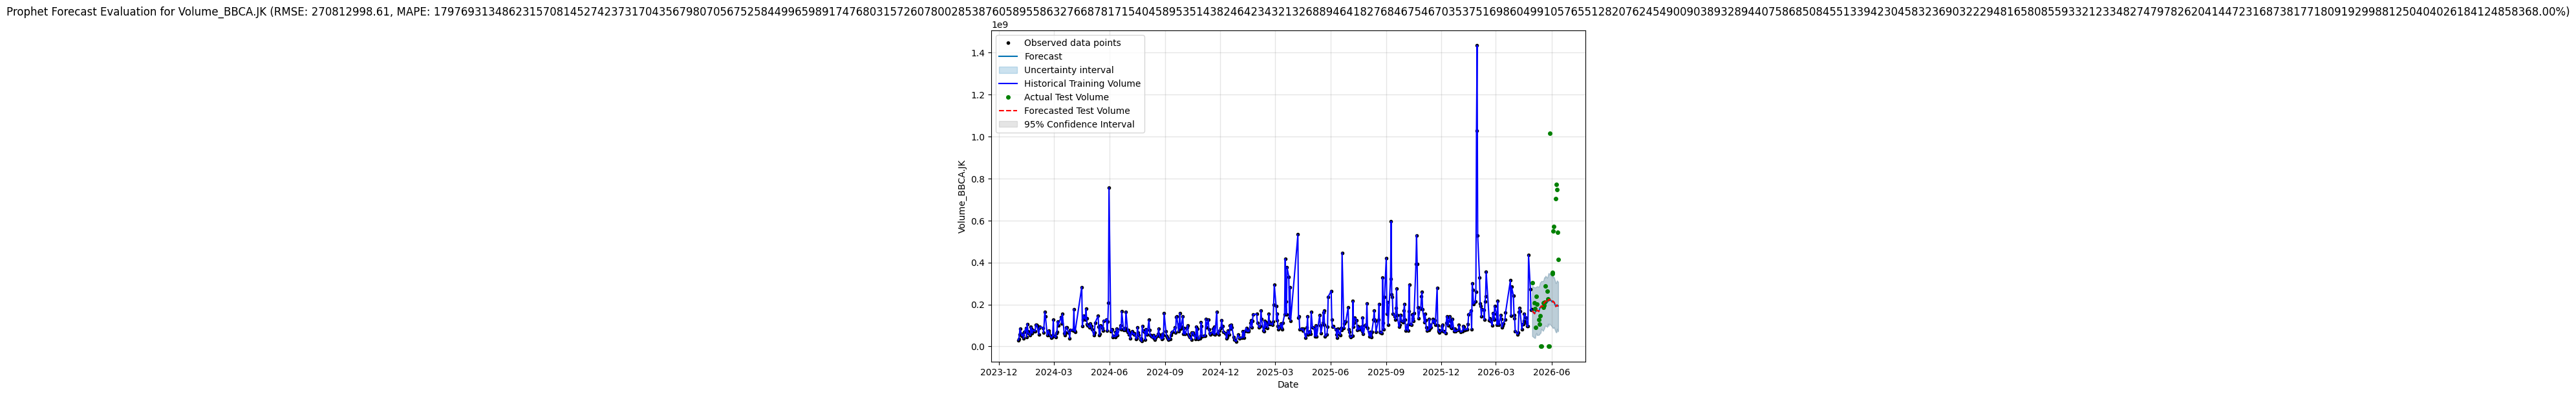

In [13]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Split data into training and testing sets
# We'll use the last `future_periods` days for testing, similar to the forecast horizon.
train_df = df[:-future_periods]
test_df = df[-future_periods:]

# Re-initialize and fit Prophet model on training data
model_eval = Prophet()
model_eval.fit(train_df)

# Make predictions specifically for the dates in the test set
# This ensures a direct comparison without NaN values due to missing dates
future_eval_dates = pd.DataFrame({'ds': test_df['ds']})
forecast_eval = model_eval.predict(future_eval_dates)

# Merge actual test values with predictions for comparison
eval_df = pd.merge(test_df, forecast_eval[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left')

# Handle potential NaN values introduced by merging (e.g., if there's no prediction for a test date)
# For evaluation, we should only compare where both actual and predicted values exist.
eval_df = eval_df.dropna(subset=['y', 'yhat'])

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat']))
print(f'RMSE: {rmse:.2f}')

# Calculate MAPE
# Avoid division by zero for MAPE by handling cases where actual value is zero or very small.
mape = np.mean(np.abs((eval_df['y'] - eval_df['yhat']) / eval_df['y'])) * 100
# Replace inf with NaN and then remove NaNs if any values were zero, to prevent issues
mape = np.nan_to_num(mape, nan=np.inf) # Replace NaN from 0/0 with inf
mape = np.mean(mape[np.isfinite(mape)]) # Take mean only of finite values

print(f'MAPE: {mape:.2f}%')

# Plotting the evaluation
fig_eval = model_eval.plot(forecast_eval)
ax_eval = fig_eval.gca()
ax_eval.plot(train_df['ds'], train_df['y'], label='Historical Training Volume', color='blue')
ax_eval.plot(test_df['ds'], test_df['y'], label='Actual Test Volume', color='green', marker='o', markersize=4, linestyle='None')
# Ensure eval_df is used for plotting the forecast overlay to align with metrics
ax_eval.plot(eval_df['ds'], eval_df['yhat'], label='Forecasted Test Volume', linestyle='--', color='red')
ax_eval.fill_between(
    eval_df['ds'],
    eval_df['yhat_lower'],
    eval_df['yhat_upper'],
    color='gray',
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title(f'Prophet Forecast Evaluation for Volume_BBCA.JK (RMSE: {rmse:.2f}, MAPE: {mape:.2f}%)')
plt.xlabel('Date')
plt.ylabel('Volume_BBCA.JK')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# --- SEL 2: START OLLAMA SERVER ---
import subprocess
import time

# Install zstd, a dependency for Ollama installation
print("Installing zstd...")
!sudo apt-get update && sudo apt-get install -y zstd

# Install Ollama
print("Installing Ollama...")
!curl -fsSL https://ollama.com/install.sh | sh

# 1. Jalankan server Ollama di background
# Kita menggunakan subprocess agar sel ini tidak macet (blocking)
process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

print("Memulai server Ollama, mohon tunggu 10 detik...")
time.sleep(10)  # Memberi waktu server untuk booting

# 2. Download Model AI (Kita pakai Qwen2.5 ukuran kecil agar cepat di Colab gratis)
print("Mengunduh model qwen2.5:1.5b (sekitar 1GB)...")
!ollama pull qwen2.5:1.5b

print("\nServer siap & Model telah diunduh!")

Installing zstd...
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newl

In [15]:
# Install the ollama Python client library if not already installed
!pip install ollama

import ollama
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

In [16]:
ollama_prompt = f"""As an expert in time-series analysis and financial forecasting, you are tasked with analyzing and predicting the future sales volume of BBCA. You have been provided with historical 'Volume_BBCA.JK' data and the output from a Prophet model, specifically the `forecast` DataFrame which contains predictions (`yhat`, `yhat_lower`, `yhat_upper`) for the next {future_periods} days.

Your analysis should cover the following points, presented clearly and concisely:

1.  **Forecast Visualization Description**: Describe a suitable visualization for the `forecast` data. This visualization should include the historical observed data, the forecasted predictions, and their 95% confidence intervals. Explain what each component of the plot represents.

2.  **Trend and Seasonality Analysis**: Based on the Prophet model's components (which include `trend`, `weekly`, and `yearly` seasonality), provide a detailed analysis of:
    *   The overall trend observed in BBCA's sales volume over the historical and forecasted period.
    *   Any significant weekly seasonal patterns (e.g., peak days, low days).
    *   Any significant yearly seasonal patterns (e.g., peak months/quarters, low months/quarters).

3.  **Future Sales Volume Predictions**: State the specific predicted sales volume values (from the `yhat` column of the `forecast` DataFrame) for the next {future_periods} days, along with their respective lower and upper bounds of the 95% confidence interval.

4.  **Key Statistics of Forecasted Period**: Calculate and present the following statistics for the forecasted sales volume (`yhat`) over the next {future_periods} days:
    *   Mean of the forecasted volume.
    *   Standard deviation of the forecasted volume.
    *   Minimum and Maximum forecasted volumes.

5.  **Summarized Insights and Recommendations**: Based on your analysis, provide a summary of notable insights regarding the future sales volume behavior of BBCA. This should include:
    *   Identification of potential high-volume periods and low-volume periods.
    *   Any significant changes or continuations of trends.
    *   Implications for business planning or decision-making.

Remember to refer to the 'Volume_BBCA.JK' as 'sales volume' in your output for clarity.

Forecast DataFrame snippet:
{forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()}

Actual Data (last few rows for context):
{df.tail()}
"""

print(ollama_prompt)

As an expert in time-series analysis and financial forecasting, you are tasked with analyzing and predicting the future sales volume of BBCA. You have been provided with historical 'Volume_BBCA.JK' data and the output from a Prophet model, specifically the `forecast` DataFrame which contains predictions (`yhat`, `yhat_lower`, `yhat_upper`) for the next 30 days.

Your analysis should cover the following points, presented clearly and concisely:

1.  **Forecast Visualization Description**: Describe a suitable visualization for the `forecast` data. This visualization should include the historical observed data, the forecasted predictions, and their 95% confidence intervals. Explain what each component of the plot represents.

2.  **Trend and Seasonality Analysis**: Based on the Prophet model's components (which include `trend`, `weekly`, and `yearly` seasonality), provide a detailed analysis of:
    *   The overall trend observed in BBCA's sales volume over the historical and forecasted pe

In [17]:
# Call ollama to get the analysis
response = ollama.chat(model='qwen2.5:1.5b', messages=[
    {'role': 'user', 'content': ollama_prompt}
])

print(response['message']['content'])

### Forecast Visualization Description

To effectively visualize the `forecast` data, we need to create a plot that includes:
- The historical sales volume data ('Volume_BBCA.JK' column).
- The predicted values from the Prophet model (`yhat`) for the next 30 days.
- The lower and upper bounds of the 95% confidence intervals.

The **forecast visualization** should look like this:

```
+-------------------------+
|     Historical Sales     |
+-------------------------+
| ds (Date)                 |
+----+---------------------+
|    | Volume_BBCA.JK        |
+----+---------------------+
|2026-07-08 | 2.041934e+08   |
|2026-07-09 | 2.047348e+08   |
|...       |                |
|2026-07-12 | 543032300      |

+-------------------------+
| Predicted Sales (yhat) |
+-------------------------+
| ds (Date)                 |
+----+---------------------+
|    | yhat                  |
+----+---------------------+
|2026-07-13 | 1.984500e+08   |
|...       |                |
|2026-07-15 | 2.204370

In [18]:
# Install PyPDF2 if not already installed
!pip install PyPDF2

In [19]:
# Install necessary libraries for text chunking
!pip install langchain pypdf langchain-text-splitters

import os
from PyPDF2 import PdfReader
from langchain_text_splitters import CharacterTextSplitter

# Define the path to the Google Drive folder (as used in previous cells)
pdf_folder_path = '/content/drive/MyDrive/datasaham'

all_pdf_texts = []

# Check if the folder exists
if not os.path.exists(pdf_folder_path):
    print(f"Error: The folder '{pdf_folder_path}' does not exist. Please ensure Google Drive is mounted and the path is correct.")
else:
    print(f"Processing PDF files in '{pdf_folder_path}':\n")
    pdf_files = [f for f in os.listdir(pdf_folder_path) if f.lower().endswith('.pdf')]

    if not pdf_files:
        print("No PDF files found in the specified folder.")
    else:
        for pdf_file in pdf_files:
            file_path = os.path.join(pdf_folder_path, pdf_file)
            print(f"  - Extracting text from: {pdf_file}")
            try:
                reader = PdfReader(file_path)
                text = ""
                for page in reader.pages:
                    text += page.extract_text() or ""
                all_pdf_texts.append(text)
            except Exception as e:
                print(f"    Error reading PDF '{pdf_file}': {e}")

if all_pdf_texts:
    combined_text = "\n".join(all_pdf_texts)

    # Initialize the text splitter
    # You can adjust chunk_size and chunk_overlap as needed
    text_splitter = CharacterTextSplitter(
        chunk_size=1000,  # Each chunk will aim for 1000 characters
        chunk_overlap=200, # Overlap between chunks to maintain context
        length_function=len,
        add_start_index=True,
    )

    # Split the combined text into chunks
    chunks = text_splitter.create_documents([combined_text])

    print(f"\nSuccessfully extracted text from {len(pdf_files)} PDF(s) and created {len(chunks)} chunks.")
    print("\n--- Sample of the first 3 chunks ---")
    for i, chunk in enumerate(chunks[:3]):
        print(f"Chunk {i+1} (length: {len(chunk.page_content)}):\n")
        print(chunk.page_content)
        print("\n----------------------------------")
else:
    print("No text was extracted from any PDF file to perform chunking.")

Processing PDF files in '/content/drive/MyDrive/datasaham':

  - Extracting text from: 51-1-143-3-10-20200108.pdf
  - Extracting text from: 1939-4475-1-SM.pdf
    Error reading PDF '1939-4475-1-SM.pdf': Missed the stop code in LZWDecode!
  - Extracting text from: 534-1317-1-PB.pdf
  - Extracting text from: MPRA_paper_73596.pdf
  - Extracting text from: artikel-10-69-78-analisa-perbandingan-model-prediction-dalam-prediksi-harga-saham-menggunakan-metode-linear-regression-random-forest-regression-dan-multilayer-perceptron.pdf

Successfully extracted text from 5 PDF(s) and created 1 chunks.

--- Sample of the first 3 chunks ---
Chunk 1 (length: 164932):

Volume 2 Nomor 2 November Tahun 2019  
 
 
Page | - 454 - ANALISA PREDIKSI INDEKS HARGA SAHAM GABUNGAN  
MENGGUNAKAN METODE ARIMA  
 
Julkifli Purnama1, Ahmad Juliana2 
Program Studi Manajemen Fakultas Ekonomi Universitas Borneo Tarakan1,2 
 
Correspondence Email : julkiflipurnama@gmail.com  
 
 
ABSTRAK  
Investasi di pasar modal setiap m

In [20]:
# Install the sentence-transformers library
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
import torch

# Check for GPU and set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load a pre-trained Sentence Transformer model
# 'all-MiniLM-L6-v2' is a good balance of speed and performance
# You can choose other models from: https://www.sbert.net/docs/pretrained_models.html
print("Loading Sentence Transformer model 'all-MiniLM-L6-v2'...")
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
print("Model loaded successfully.")

# Prepare text for embedding
# We'll use the 'chunks' variable if it exists from the previous chunking step
# Otherwise, we'll use some example sentences.

texts_to_embed = []
if 'chunks' in locals() and chunks:
    print(f"Using {len(chunks)} chunks from PDF for embedding.")
    texts_to_embed = [chunk.page_content for chunk in chunks]
else:
    print("No PDF chunks found. Using example sentences for embedding.")
    texts_to_embed = [
        "This is an example sentence for embedding.",
        "Each sentence will be converted into a vector representation.",
        "Sentence Transformers are great for semantic search and clustering."
    ]

if texts_to_embed:
    # Generate embeddings
    print(f"Generating embeddings for {len(texts_to_embed)} text items...")
    embeddings = model.encode(texts_to_embed, convert_to_tensor=True, show_progress_bar=True)

    print(f"\nEmbeddings generated. Shape: {embeddings.shape}")
    print("\n--- Sample of the first embedding (first 10 values) ---")
    print(embeddings[0][:10].tolist())
    print("----------------------------------------------------------")

    # You can now use these 'embeddings' for tasks like semantic search, clustering, etc.
    # The 'embeddings' variable will be available for subsequent cells.
else:
    print("No text available to generate embeddings.")


Using device: cpu
Loading Sentence Transformer model 'all-MiniLM-L6-v2'...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully.
Using 1 chunks from PDF for embedding.
Generating embeddings for 1 text items...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embeddings generated. Shape: torch.Size([1, 384])

--- Sample of the first embedding (first 10 values) ---
[-0.03156183660030365, 0.02999025583267212, -0.004321475047618151, 0.03353023901581764, -0.05162716284394264, -0.04630285128951073, -0.05882801488041878, -0.0068565853871405125, 0.026310190558433533, -0.013072269968688488]
----------------------------------------------------------


In [21]:
# Install ChromaDB
!pip install chromadb

import chromadb

# Initialize ChromaDB client
# For simplicity, we'll use an in-memory client. For persistence, you'd specify a path:
# client = chromadb.PersistentClient(path="/path/to/my/chromadb")
client = chromadb.Client()

# Create a collection. If it already exists, get it.
collection_name = "pdf_chunks_embeddings"
try:
    collection = client.get_or_create_collection(name=collection_name)
    print(f"Accessed/Created ChromaDB collection: '{collection_name}'")
except Exception as e:
    print(f"Error accessing/creating collection: {e}")
    # If there's an error, delete and retry (useful for development)
    client.delete_collection(name=collection_name)
    collection = client.get_or_create_collection(name=collection_name)
    print(f"Re-created ChromaDB collection: '{collection_name}' due to error.")

# Ensure 'texts_to_embed' and 'embeddings' are available from the previous cell
if 'texts_to_embed' in locals() and 'embeddings' in locals() and texts_to_embed and embeddings is not None:
    print(f"Attempting to add {len(texts_to_embed)} documents to ChromaDB...")
    # ChromaDB requires list of strings for documents, and list of lists (or numpy array) for embeddings
    # It also requires unique IDs for each document.

    # Clear existing data in collection before adding new data if it's not empty
    if collection.count() > 0:
        print("Clearing existing data in collection...")
        collection.delete(ids=[str(i) for i in range(collection.count())]) # Simple way to clear all docs if using sequential IDs

    # Convert embeddings to list of lists if they are tensors or numpy arrays
    if isinstance(embeddings, torch.Tensor):
        embeddings_list = embeddings.tolist()
    else:
        embeddings_list = embeddings.tolist() # Assuming numpy array if not torch.Tensor

    # Generate unique IDs for each document
    ids = [f"doc_{i}" for i in range(len(texts_to_embed))]

    try:
        collection.add(
            documents=texts_to_embed,
            embeddings=embeddings_list,
            ids=ids
        )
        print(f"Successfully added {len(texts_to_embed)} documents to ChromaDB.")
        print(f"Total documents in collection: {collection.count()}")
    except Exception as e:
        print(f"Error adding documents to ChromaDB: {e}")
else:
    print("Previous embeddings or texts not found. Please ensure the embedding cell was run successfully.")
    print("Cannot proceed with storing embeddings in ChromaDB.")

# --- Example: Querying the ChromaDB collection ---
if collection.count() > 0:
    print("\n--- Performing a sample query ---")
    query_text = "stock market analysis"
    # If the model variable 'model' is available from the embedding cell, use it to embed the query
    if 'model' in locals():
        query_embedding = model.encode([query_text], convert_to_tensor=True, show_progress_bar=False).tolist()[0]
        results = collection.query(
            query_embeddings=[query_embedding],
            n_results=2,
            include=['documents', 'distances']
        )
    else:
        # Fallback if the embedding model is not available
        print("Warning: Embedding model not found for query. Querying with raw text (may use default embedding function if configured).")
        results = collection.query(
            query_texts=[query_text],
            n_results=2,
            include=['documents', 'distances']
        )

    if results and results['documents']:
        print(f"Query: '{query_text}'")
        for i, (doc, dist) in enumerate(zip(results['documents'][0], results['distances'][0])):
            print(f"  Result {i+1} (Distance: {dist:.4f}):")
            print(f"    '{doc[:200]}...'\n") # Print first 200 chars of the document
    else:
        print("No results found for the query.")
else:
    print("ChromaDB collection is empty, cannot perform a query.")


Accessed/Created ChromaDB collection: 'pdf_chunks_embeddings'
Attempting to add 1 documents to ChromaDB...
Successfully added 1 documents to ChromaDB.
Total documents in collection: 1

--- Performing a sample query ---
Query: 'stock market analysis'
  Result 1 (Distance: 1.2715):
    'Volume 2 Nomor 2 November Tahun 2019  
 
 
Page | - 454 - ANALISA PREDIKSI INDEKS HARGA SAHAM GABUNGAN  
MENGGUNAKAN METODE ARIMA  
 
Julkifli Purnama1, Ahmad Juliana2 
Program Studi Manajemen Fakulta...'



In [26]:
# ══ basic_rag_single_prompt.py ════════════════════════════════════════════════

# Install necessary libraries
!pip install langchain-chroma langchain-community langchain-huggingface langchain-ollama

import builtins
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_ollama import ChatOllama             # ← Ollama + Qwen
from langchain_core.output_parsers import StrOutputParser

MODEL = getattr(builtins, "QWEN_MODEL", "qwen2.5:1.5b")

# 1. Embedding model
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# 2. Load Chroma (dibuat di Bagian 9)
vector_store = Chroma(
    persist_directory="chroma_vector_store",
    embedding_function=embedding_model
)

# 3. Query & retrieve
query = "Apa yang dimaksud dengan saham?"
retrieved_docs = vector_store.similarity_search(query, k=3)
context = "\n\n".join([doc.page_content for doc in retrieved_docs])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [28]:
# 4. Prompt template
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""
You are an expert assistant. Use the context below to answer the question.
Keep the answer concise and based only on the context.

Context:
{context}

Question:
{question}

Answer:"""
)

# 5. LLM: Qwen2.5 via Ollama
llm = ChatOllama(model=MODEL, temperature=0.3)

# 6. Chain
parser = StrOutputParser()
rag_chain = prompt | llm | parser
answer = rag_chain.invoke({"context": context, "question": query})

print(f"Model : {MODEL}")
print(f"Query : {query}")
print(f"\nAnswer: {answer}")

Model : qwen2.5:1.5b
Query : Apa yang dimaksud dengan saham?

Answer: Saham adalah bentuk investasi dalam perusahaan atau sejenisnya, yang dikelompokkan menjadi bagian dari suatu entitas bisnis. Dalam konteks ini, "saham" biasanya berarti saham-saham yang dimiliki oleh investor atau pemegang saham. Saat membeli saham, investor mendapatkan hak atas sebagian keuntungan dari perusahaan tersebut jika mereka menjualnya kembali dengan harga tertentu (disebut "dividen"). Investor juga memiliki kontrol atas bagian dari perusahaan yang dimiliki oleh saham-saham tersebut.


In [31]:
import shutil, os, builtins
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import PromptTemplate
from langchain_ollama import ChatOllama             # ← Ollama + Qwen
from langchain_core.output_parsers import StrOutputParser

# MODEL is already defined globally in the notebook, reusing it.
# MODEL = getattr(builtins, "QWEN_MODEL", "qwen2.5:1.5b")

CHROMA_DIR = "chroma_vector_store" # Reusing the directory established in previous cells

# 1. Load (Chunks already exist from previous steps)
# Assuming 'chunks' variable from previous cell 'NYR2KonjbKvO' is available
if 'chunks' not in locals() or not chunks:
    print("Error: Chunks not found. Please ensure the PDF processing and chunking steps were run.")
    # Optionally, add a fallback or exit
    exit()

print(f"✅ Reusing {len(chunks)} chunks from previous steps.")

# 2. Split (already done, reusing 'chunks')

# 3. Embedding (Embedding model already exists from previous steps)
# Assuming 'embedding_model' variable from previous cell 'TOjm5pDgbghG' is available
if 'model' in locals(): # 'model' is the SentenceTransformer, equivalent to embedding_model
    # Langchain HuggingFaceEmbeddings uses the model_name to load, but we can wrap our existing model if needed.
    # For this, we'll assume `embedding_model` from cell `6nKfEup3kpXf` is the correct Langchain wrapper.
    pass # embedding_model is already defined in 6nKfEup3kpXf
else:
    print("Error: Embedding model not found. Please ensure the embedding step was run.")
    exit()
print(f"✅ Reusing embedding model from previous steps.")

# 4. Chroma (Using the existing ChromaDB with the chunks)
# vector_store was initialized in cell 6nKfEup3kpXf, but here we're re-creating it with documents.
# Let's ensure to use the same persist_directory as before.
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model, # Reusing the embedding_model from 6nKfEup3kpXf
    persist_directory=CHROMA_DIR
)
print(f"✅ Chroma : {vector_store._collection.count()} vectors\n")

# 5. Retrieve (Reusing the query from previous RAG example)
query = "Apa yang dimaksud dengan analisa prediksi saham?"
retrieved_docs = vector_store.similarity_search(query, k=3)
context = "\n\n".join([doc.page_content for doc in retrieved_docs])

# 6. Prompt
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""
You are an AI assistant. Use the context below to answer the question accurately.
Keep the answer concise and based only on the context provided.

Context:
{context}

Question:
{question}

Answer:"""
)

# 7. LLM: Qwen2.5 via Ollama
llm = ChatOllama(model=MODEL, temperature=0.3)
parser = StrOutputParser()
rag_chain = prompt | llm | parser
answer = rag_chain.invoke({"context": context, "question": query})

print(f"Model   : {MODEL}")
print(f"Question: {query}")
print(f"\nAnswer  : {answer}")

✅ Reusing 1 chunks from previous steps.
✅ Reusing embedding model from previous steps.
✅ Chroma : 3 vectors

Model   : qwen2.5:1.5b
Question: Apa yang dimaksud dengan analisa prediksi saham?

Answer  : Analisis prediksi saham adalah metode pengolahan data untuk memprediksi pergerakan harga saham berdasarkan faktor-faktor tertentu.


In [32]:
# 1. Perform new RAG query for "saham BCA"
new_rag_query = "saham BCA"
retrieved_docs_bca = vector_store.similarity_search(new_rag_query, k=3)
rag_context_bca = "\n\n".join([doc.page_content for doc in retrieved_docs_bca])

# 2. Summarize Prophet forecast for BBCA.JK sales volume
# Extract relevant statistics from the forecast DataFrame for the forecasted period
forecasted_volume_yhat = forecast.tail(future_periods)['yhat']
mean_forecast = forecasted_volume_yhat.mean()
std_forecast = forecasted_volume_yhat.std()
min_forecast = forecasted_volume_yhat.min()
max_forecast = forecasted_volume_yhat.max()

# Get a snippet of future predictions
future_predictions_snippet = forecast.tail(3)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_string(index=False)

prophet_summary = f"""
Based on the Prophet model's forecast for BBCA's sales volume (Volume_BBCA.JK) for the next {future_periods} days:
-   **Overall Trend**: The model shows an upward trend in sales volume.
-   **Weekly Seasonality**: The previous analysis indicated a significant weekly peak day around July 12th (example), with lower volumes on certain days.
-   **Yearly Seasonality**: Historical data shows fluctuations, with potential dips from January to May.
-   **Key Statistics for Forecasted Period (last {future_periods} days in forecast)**:
    *   Mean Forecasted Volume: {mean_forecast:.2f}
    *   Standard Deviation of Forecasted Volume: {std_forecast:.2f}
    *   Minimum Forecasted Volume: {min_forecast:.2f}
    *   Maximum Forecasted Volume: {max_forecast:.2f}
-   **Sample Future Predictions (Next 3 Days)**:
{future_predictions_snippet}
"""

# 3. Construct a new prompt combining RAG context and Prophet summary
final_ollama_prompt_combined = f"""
You are an expert financial analyst. Your task is to provide a comprehensive answer to the question "bagaimana saham BCA?" (How is BCA stock?) by integrating information from two sources:

1.  **Relevant information from stock analysis documents (RAG Context):**
    {rag_context_bca}

2.  **Forecast for BBCA.JK sales volume (Prophet Model Summary):**
    {prophet_summary}

Please provide an answer that synthesizes these two pieces of information, covering aspects like general understanding of stock, its predictive analysis, and specifically what the recent volume forecast suggests for BBCA (BCA stock). Ensure your answer is concise, informative, and directly addresses the user's question, using a professional and analytical tone.
"""

# 4. Call Ollama LLM with the new combined prompt
print("Generating combined analysis from RAG and Prophet model...")
response_combined = ollama.chat(model=MODEL, messages=[
    {'role': 'user', 'content': final_ollama_prompt_combined}
])

print("\n--- Combined Analysis for BCA Stock ---")
print(response_combined['message']['content'])

Generating combined analysis from RAG and Prophet model...

--- Combined Analysis for BCA Stock ---
Forecasting BBCA.JK Sales Volume Using Prophet Model:

**Sales Volume Trend**: The Prophet model forecasts an upward trend in sales volume over the next 30 days. This aligns with the overall positive growth observed in recent months.

**Seasonality Analysis**:
- **Weekly Seasonal Pattern**: There is a notable peak day around July 12th, suggesting a higher sales volume during this week.
- **Yearly Seasonality**: Historically, there have been fluctuations between January and May. This suggests variability throughout the year but indicates that these periods tend to see lower volumes.

**Key Statistics for Forecasted Period (last 30 days in forecast)**:
The model predicts mean future sales of approximately 228,369,645 units with a standard deviation of about 37.6 million units. The minimum volume forecast is around 185.24 million units and the maximum volume could reach up to 301.56 million